# 6CS012 — Final Portfolio Assessment Part III
## Sentiment Analysis of IMDb Movie Reviews using RNN, LSTM, and GloVe Embeddings
## ID: 2434743 | Name: Chirag Lama
**Herald College Kathmandu | University of Wolverhampton**


In [ ]:


!pip install --upgrade jax jaxlib
!pip install gensim wordcloud


In [ ]:
# ── Standard Libraries ──
import os
import re
import string
import warnings
import time
import pickle
warnings.filterwarnings('ignore')

# ── Data Handling ──
import numpy as np
import pandas as pd
import gradio as gr

# ── Visualization ──
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter

# ── NLP Preprocessing ──
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# ── Scikit-Learn ──
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, ConfusionMatrixDisplay)
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.regularizers import l2

# ── Keras / TensorFlow ──
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Embedding, SimpleRNN, LSTM,
                                     Dense, Dropout, Bidirectional,Input)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import load_model

# ── Gensim (Word2Vec) ──
import gensim.downloader as api

print("All libraries imported successfully!")
print(f"TensorFlow version: {tf.__version__}")
print(f"NumPy version: {np.__version__}")


All libraries imported successfully!
TensorFlow version: 2.20.0
NumPy version: 2.0.2


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


---
## 2. Load Dataset

The **IMDb Movie Review Dataset** is a binary sentiment analysis dataset.  
- **Labels:** `0` = Negative, `1` = Positive  
- **Split:** Pre-split into Train / Validation / Test sets


In [ ]:


TRAIN_PATH = '/content/drive/MyDrive/Semester6_AI ML/Assesment/5. Movie Review Dataset-20260507T112750Z-3-001/5. Movie Review Dataset/train_movie_review.csv'   # Update path if needed
VAL_PATH   = '/content/drive/MyDrive/Semester6_AI ML/Assesment/5. Movie Review Dataset-20260507T112750Z-3-001/5. Movie Review Dataset/val_movie_review.csv'
TEST_PATH  = '/content/drive/MyDrive/Semester6_AI ML/Assesment/5. Movie Review Dataset-20260507T112750Z-3-001/5. Movie Review Dataset/test_movie_review.csv'

# ── Load CSV files ──
train_df = pd.read_csv(TRAIN_PATH)
val_df   = pd.read_csv(VAL_PATH)
test_df  = pd.read_csv(TEST_PATH)

# Drop unnecessary index column if present
for df in [train_df, val_df, test_df]:
    if 'Unnamed: 0' in df.columns:
        df.drop(columns=['Unnamed: 0'], inplace=True)

# Combine train + val, then re-split properly 80/20
full_df = pd.concat([train_df, val_df], ignore_index=True).sample(frac=1, random_state=42)
split = int(len(full_df) * 0.8)
train_df = full_df[:split]
val_df   = full_df[split:]

print(f"Train size : {len(train_df)}")
print(f"Val size   : {len(val_df)}")
print("\nTrain Label Distribution:")
print(train_df['sentiment'].value_counts())
print("\nVal Label Distribution:")
print(val_df['sentiment'].value_counts())

print("=" * 50)
print(f"  Train set shape : {train_df.shape}")
print(f"  Val   set shape : {val_df.shape}")
print(f"  Test  set shape : {test_df.shape}")
print("=" * 50)
print("\nSample rows from training set:")
print(train_df.head(3))

Train size : 32000
Val size   : 8000

Train Label Distribution:
sentiment
0    16012
1    15988
Name: count, dtype: int64

Val Label Distribution:
sentiment
0    4027
1    3973
Name: count, dtype: int64
  Train set shape : (32000, 2)
  Val   set shape : (8000, 2)
  Test  set shape : (10000, 2)

Sample rows from training set:
                                                  review  sentiment
32823  I remember watching this film a while ago and ...          1
16298  Man, I loved this movie! This really takes me ...          1
28505  Perhaps the director was trying for another PI...          0


In [ ]:
# ── Basic Info ──
print("Column names :", train_df.columns.tolist())
print("\nMissing values in train:")
print(train_df.isnull().sum())
print("\nData types:")
print(train_df.dtypes)


Column names : ['review', 'sentiment']

Missing values in train:
review       0
sentiment    0
dtype: int64

Data types:
review       object
sentiment     int64
dtype: object


---
## 3. Exploratory Data Analysis (EDA)


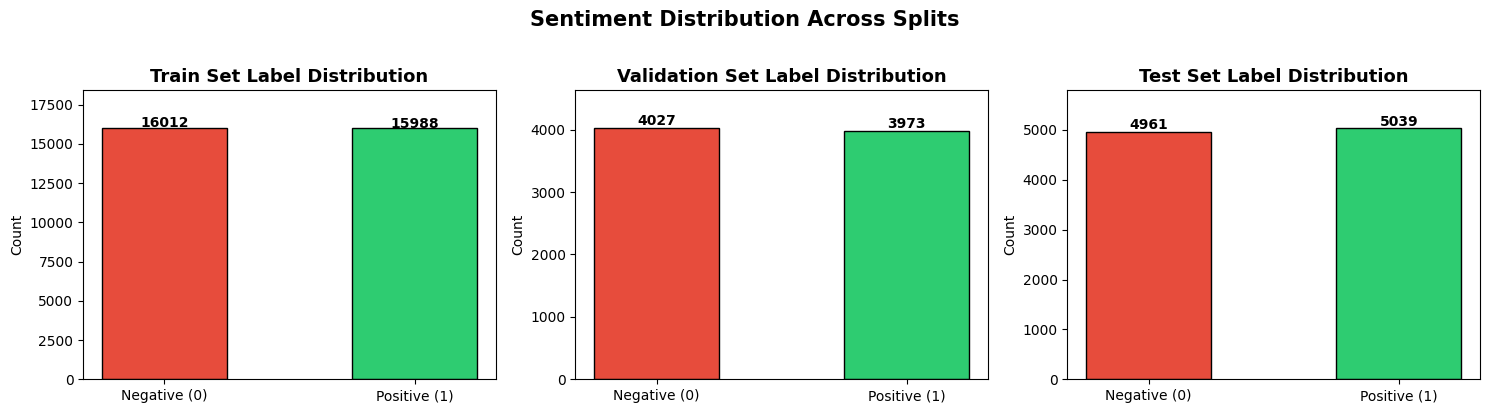

Dataset is well balanced — no class imbalance issue!


In [ ]:
# ── Label Distribution ──
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
datasets = {'Train': train_df, 'Validation': val_df, 'Test': test_df}
colors = ['#e74c3c', '#2ecc71']

for ax, (name, df) in zip(axes, datasets.items()):
    counts = df['sentiment'].value_counts().sort_index()
    ax.bar(['Negative (0)', 'Positive (1)'], counts.values, color=colors, edgecolor='black', width=0.5)
    ax.set_title(f'{name} Set Label Distribution', fontsize=13, fontweight='bold')
    ax.set_ylabel('Count')
    for i, v in enumerate(counts.values):
        ax.text(i, v + 50, str(v), ha='center', fontweight='bold')
    ax.set_ylim(0, counts.max() * 1.15)

plt.suptitle('Sentiment Distribution Across Splits', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Dataset is well balanced — no class imbalance issue!")


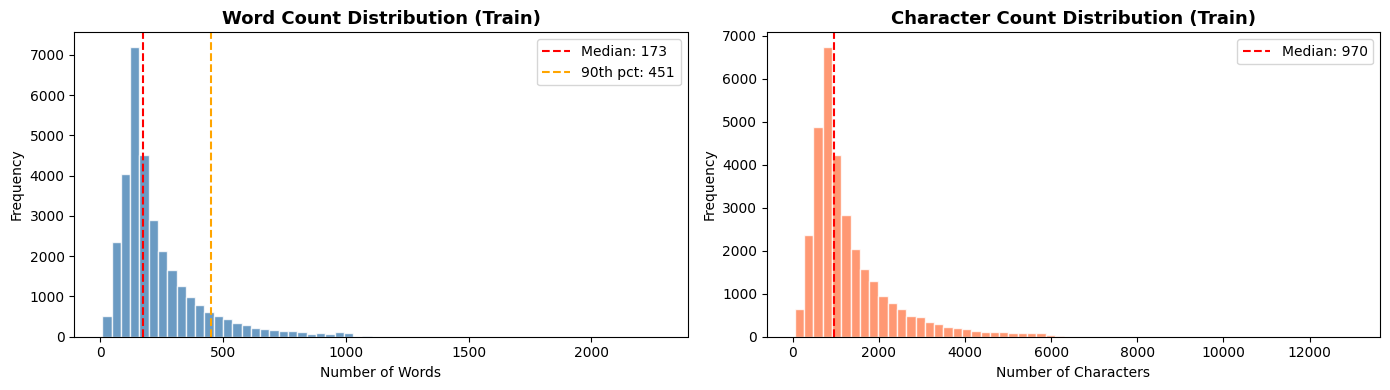

Word count stats:
count    32000.0
mean       231.0
std        171.5
min          8.0
25%        126.0
50%        173.0
75%        280.0
max       2278.0
Name: word_count, dtype: float64

50th percentile : 173 words
90th percentile : 451 words
95th percentile : 591 words


In [ ]:
# ── Review Length Analysis ──
train_df['word_count'] = train_df['review'].str.split().str.len()
train_df['char_count'] = train_df['review'].str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(train_df['word_count'], bins=60, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(train_df['word_count'].median(), color='red', linestyle='--', label=f"Median: {int(train_df['word_count'].median())}")
axes[0].axvline(np.percentile(train_df['word_count'], 90), color='orange', linestyle='--', label=f"90th pct: {int(np.percentile(train_df['word_count'], 90))}")
axes[0].set_title('Word Count Distribution (Train)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Words')
axes[0].set_ylabel('Frequency')
axes[0].legend()

axes[1].hist(train_df['char_count'], bins=60, color='coral', edgecolor='white', alpha=0.8)
axes[1].axvline(train_df['char_count'].median(), color='red', linestyle='--', label=f"Median: {int(train_df['char_count'].median())}")
axes[1].set_title('Character Count Distribution (Train)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Characters')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.savefig('length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Word count stats:\n{train_df['word_count'].describe().round(1)}")
print(f"\n50th percentile : {np.percentile(train_df['word_count'], 50):.0f} words")
print(f"90th percentile : {np.percentile(train_df['word_count'], 90):.0f} words")
print(f"95th percentile : {np.percentile(train_df['word_count'], 95):.0f} words")


---
## 4. Text Preprocessing, Tokenization, and Sequence Padding

### 4.1 Text Cleaning

The following steps are applied to clean the raw review text:
1. **Lowercase** — Normalize case
2. **Remove HTML tags** — Reviews contain `<br />` tags
3. **Remove URLs** — Strip hyperlinks
4. **Remove mentions & hashtags** — @user, #tag
5. **Handle contractions** — don't → do not
6. **Remove numbers & special characters**
7. **Remove stopwords** — Common words with little semantic value
8. **Lemmatize** — Reduce words to base form


In [ ]:
# ── Contractions dictionary ──
CONTRACTIONS = {
    "don't": "do not", "doesn't": "does not", "didn't": "did not",
    "won't": "will not", "wouldn't": "would not", "can't": "cannot",
    "couldn't": "could not", "shouldn't": "should not", "isn't": "is not",
    "aren't": "are not", "wasn't": "was not", "weren't": "were not",
    "haven't": "have not", "hasn't": "has not", "hadn't": "had not",
    "I'm": "I am", "I've": "I have", "I'll": "I will", "I'd": "I would",
    "it's": "it is", "that's": "that is", "there's": "there is",
    "they're": "they are", "they've": "they have", "they'll": "they will",
    "we're": "we are", "we've": "we have", "we'll": "we will",
    "you're": "you are", "you've": "you have", "you'll": "you will",
    "he's": "he is", "she's": "she is", "who's": "who is",
    "what's": "what is", "let's": "let us", "could've": "could have",
    "should've": "should have", "would've": "would have",
}

stop_words  = set(stopwords.words('english'))
lemmatizer  = WordNetLemmatizer()

def expand_contractions(text):
    for contraction, expansion in CONTRACTIONS.items():
        text = re.sub(re.escape(contraction), expansion, text, flags=re.IGNORECASE)
    return text

def clean_text(text):
    text = str(text).lower()                                         # 1. Lowercase
    text = re.sub(r'<.*?>', ' ', text)                               # 2. Remove HTML tags
    text = re.sub(r'http\S+|www\.\S+', '', text)                     # 3. Remove URLs
    text = re.sub(r'@\w+|#\w+', '', text)                            # 4. Remove mentions/hashtags
    text = expand_contractions(text)                                  # 5. Expand contractions
    text = re.sub(r'[^a-z\s]', ' ', text)                            # 6. Remove numbers & special chars
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens               # 7. Lemmatize
              if w not in stop_words and len(w) > 2]                 # 8. Remove stopwords & short words
    return ' '.join(tokens)

print("Cleaning texts — this may take 1-2 minutes...")
t0 = time.time()
train_df['clean_review'] = train_df['review'].apply(clean_text)
val_df['clean_review']   = val_df['review'].apply(clean_text)
test_df['clean_review']  = test_df['review'].apply(clean_text)
print(f"Done in {time.time()-t0:.1f}s")

print("\nOriginal review:")
print(train_df['review'].iloc[0][:300])
print("\nCleaned review:")
print(train_df['clean_review'].iloc[0][:300])


Cleaning texts — this may take 1-2 minutes...
Done in 91.6s

Original review:
I remember watching this film a while ago and after seeing 3000 miles to Graceland, it all came flooding back. Why this hasn't had a Video or DVD release yet? It's sacrilegious that this majesty of movie making has never been released while other rubbish has been. In fact this is the one John Carpen

Cleaned review:
remember watching film ago seeing mile graceland came flooding back video dvd release yet sacrilegious majesty movie making never released rubbish fact one john carpenter film released fact seen either since day watched kurt russell perfect choice role elvis definitely role born play john carpenter 


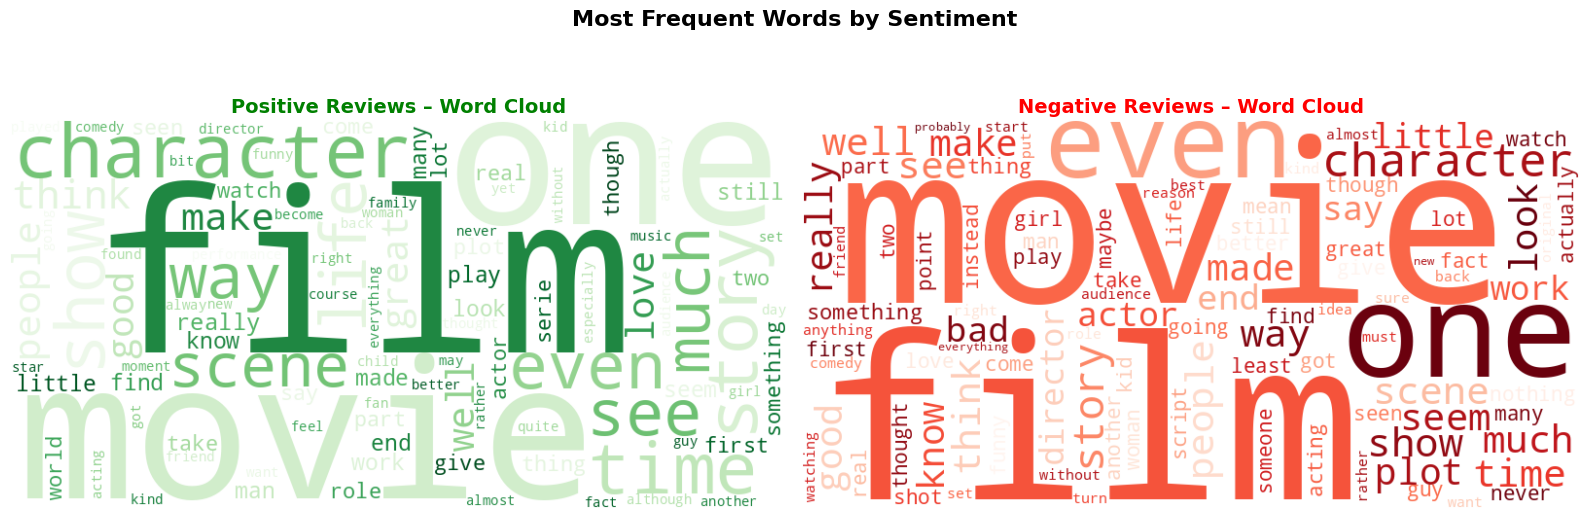

In [ ]:
# ── Word Cloud ──
pos_text = ' '.join(train_df[train_df['sentiment'] == 1]['clean_review'])
neg_text = ' '.join(train_df[train_df['sentiment'] == 0]['clean_review'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

wc_pos = WordCloud(width=800, height=400, background_color='white',
                   colormap='Greens', max_words=100).generate(pos_text)
axes[0].imshow(wc_pos, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Positive Reviews – Word Cloud', fontsize=14, fontweight='bold', color='green')

wc_neg = WordCloud(width=800, height=400, background_color='white',
                   colormap='Reds', max_words=100).generate(neg_text)
axes[1].imshow(wc_neg, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Negative Reviews – Word Cloud', fontsize=14, fontweight='bold', color='red')

plt.suptitle('Most Frequent Words by Sentiment', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('wordcloud.png', dpi=150, bbox_inches='tight')
plt.show()


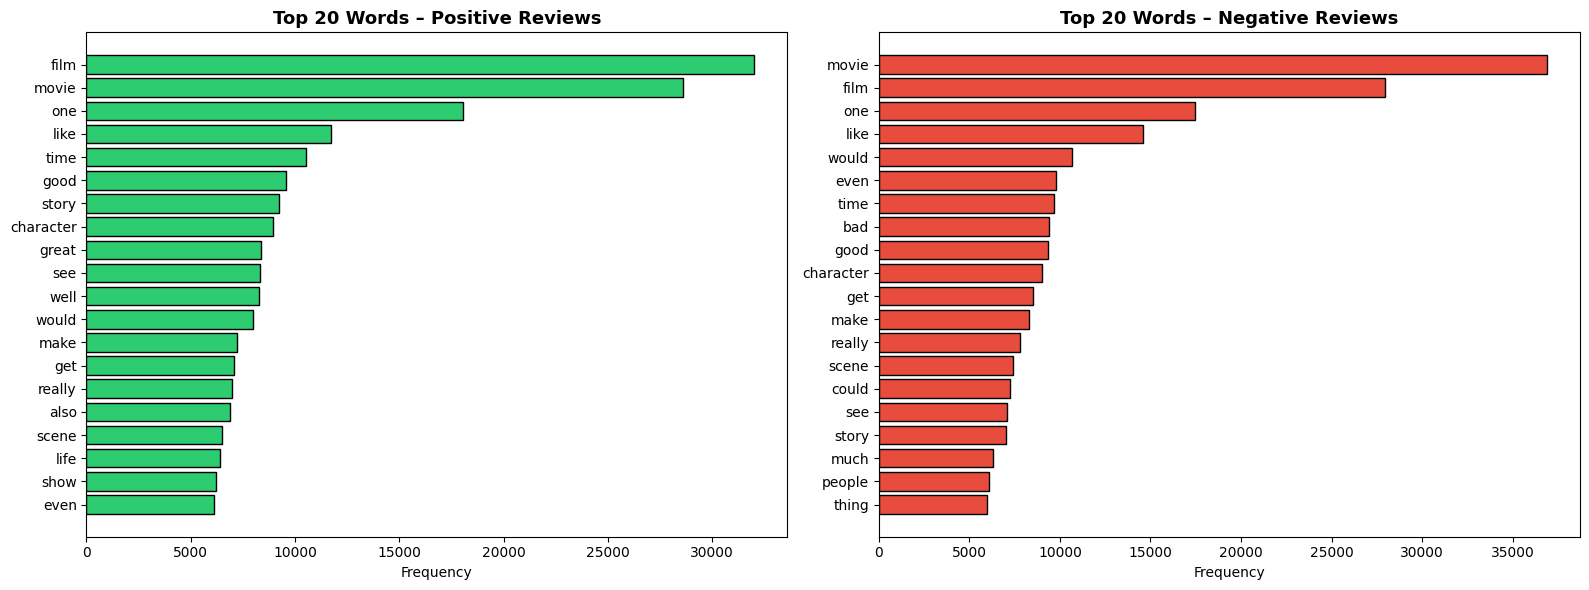

In [ ]:
# ── Top 20 Most Frequent Words (Positive vs Negative) ──
def get_top_words(df, label, n=20):
    text = ' '.join(df[df['sentiment'] == label]['clean_review'])
    counts = Counter(text.split())
    return counts.most_common(n)

top_pos = get_top_words(train_df, 1)
top_neg = get_top_words(train_df, 0)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

words_p, counts_p = zip(*top_pos)
axes[0].barh(words_p[::-1], counts_p[::-1], color='#2ecc71', edgecolor='black')
axes[0].set_title('Top 20 Words – Positive Reviews', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Frequency')

words_n, counts_n = zip(*top_neg)
axes[1].barh(words_n[::-1], counts_n[::-1], color='#e74c3c', edgecolor='black')
axes[1].set_title('Top 20 Words – Negative Reviews', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Frequency')

plt.tight_layout()
plt.savefig('top_words.png', dpi=150, bbox_inches='tight')
plt.show()


### 4.2 Tokenization and Sequence Padding

In [ ]:
# ── Tokenizer Configuration ──
VOCAB_SIZE  = 20000   # Top 20k most frequent words
OOV_TOKEN   = '<OOV>'

# Padding length: use 90th percentile of training word counts → 300
# This avoids overly long sequences while covering most reviews
MAX_LEN = 150

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token=OOV_TOKEN)
tokenizer.fit_on_texts(train_df['clean_review'])

word_index = tokenizer.word_index
print(f"Total unique vocabulary size : {len(word_index):,}")
print(f"Vocabulary used (capped at)  : {VOCAB_SIZE:,}")
print(f"Max sequence length (MAX_LEN): {MAX_LEN}")

# ── Convert to sequences ──
X_train_seq = tokenizer.texts_to_sequences(train_df['clean_review'])
X_val_seq   = tokenizer.texts_to_sequences(val_df['clean_review'])
X_test_seq  = tokenizer.texts_to_sequences(test_df['clean_review'])

# ── Pad sequences ──
X_train = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_val   = pad_sequences(X_val_seq,   maxlen=MAX_LEN, padding='post', truncating='post')
X_test  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding='post', truncating='post')

y_train = train_df['sentiment'].values
y_val   = val_df['sentiment'].values
y_test  = test_df['sentiment'].values

print(f"\nX_train shape : {X_train.shape}")
print(f"X_val   shape : {X_val.shape}")
print(f"X_test  shape : {X_test.shape}")
print(f"y_train shape : {y_train.shape}")


Total unique vocabulary size : 74,194
Vocabulary used (capped at)  : 20,000
Max sequence length (MAX_LEN): 150

X_train shape : (32000, 150)
X_val   shape : (8000, 150)
X_test  shape : (10000, 150)
y_train shape : (32000,)


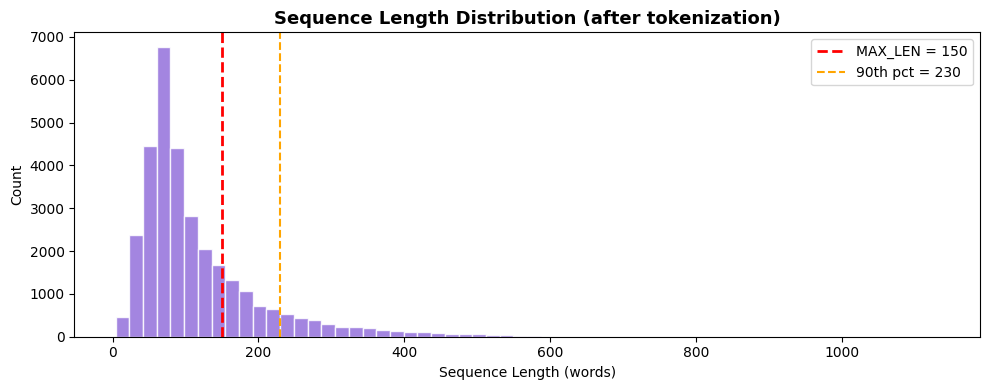

Sequences <= MAX_LEN (150): 77.3% of reviews covered


In [ ]:
# ── Visualize sequence length distribution after padding ──
seq_lens = [len(s) for s in X_train_seq]

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(seq_lens, bins=60, color='mediumpurple', edgecolor='white', alpha=0.85)
ax.axvline(MAX_LEN, color='red', linestyle='--', linewidth=2, label=f'MAX_LEN = {MAX_LEN}')
ax.axvline(np.percentile(seq_lens, 90), color='orange', linestyle='--',
           label=f'90th pct = {int(np.percentile(seq_lens,90))}')
ax.set_title('Sequence Length Distribution (after tokenization)', fontsize=13, fontweight='bold')
ax.set_xlabel('Sequence Length (words)')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.savefig('seq_length.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Sequences <= MAX_LEN ({MAX_LEN}): {sum(l<=MAX_LEN for l in seq_lens)/len(seq_lens)*100:.1f}% of reviews covered")


In [ ]:
# Diagnostic: find optimal MAX_LEN

lengths = (X_train != 0).sum(axis=1)
print("Mean length:       ", lengths.mean())
print("Median length:     ", np.median(lengths))
print("95th percentile:   ", np.percentile(lengths, 95))
print("Max length:        ", lengths.max())

# Then update MAX_LEN if needed
MAX_LEN = int(np.percentile(lengths, 95))
print("New MAX_LEN:", MAX_LEN)

# Re-pad with new MAX_LEN

X_train = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_val   = pad_sequences(X_val_seq,   maxlen=MAX_LEN, padding='post', truncating='post')
X_test  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding='post', truncating='post')

Mean length:        94.6431875
Median length:      87.0
95th percentile:    150.0
Max length:         150
New MAX_LEN: 150


---
## 5. Model Building and Training

Three models are built as required:
| Model | Architecture |
|-------|-------------|
| **Model 1** | Simple RNN + Trainable Embedding |
| **Model 2** | LSTM + Trainable Embedding |
| **Model 3** | LSTM + Pre-trained Word2Vec (GloVe) Embeddings |


### 5.1 Model 1 – Simple RNN with Trainable Embedding

In [ ]:


# ── Hyperparameters ──
EMBEDDING_DIM = 128
BATCH_SIZE    = 64
EPOCHS        = 20

RNN_MAX_LEN = 100
X_train_rnn = X_train[:, :RNN_MAX_LEN]
X_val_rnn   = X_val[:,   :RNN_MAX_LEN]
X_test_rnn  = X_test[:,  :RNN_MAX_LEN]


def get_callbacks(name):
    if name == 'rnn':
        return [
            EarlyStopping(
                monitor='val_loss',
                patience=2,
                restore_best_weights=True,
                verbose=1,
                mode='min'
            )
        ]
    else:
        return [
            EarlyStopping(
                monitor='val_loss',
                patience=4,
                restore_best_weights=True,
                verbose=1,
                mode='min'
            ),
            ReduceLROnPlateau(
                monitor='val_loss',
                factor=0.5,
                patience=2,
                min_lr=1e-6,
                verbose=1
            )
        ]

# ── Model 1: Simple RNN ──
tf.keras.backend.clear_session()
model1 = Sequential(name='Simple_RNN')
model1.add(Input(shape=(RNN_MAX_LEN,)))
model1.add(Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM))
model1.add(SimpleRNN(64, activation='tanh', return_sequences=True))
model1.add(SimpleRNN(32, activation='tanh', return_sequences=False))
model1.add(Dropout(0.4))
model1.add(Dense(64, activation='relu'))
model1.add(Dropout(0.3))
model1.add(Dense(1, activation='sigmoid'))

model1.compile(
    optimizer=Adam(learning_rate=3e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model1.summary()

Model: "Simple_RNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 100, 64)        │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 32)             │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,577,633 (9.83 MB)

 Trainable params: 2,577,633 (9.83 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ── Train Model 1 ──
print("Training Model 1: Simple RNN...")
t_start = time.time()

history1 = model1.fit(
  X_train_rnn, y_train,
    validation_data=(X_val_rnn, y_val),
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    callbacks=get_callbacks('rnn'),
    verbose=1
)

m1_time = time.time() - t_start
print(f"\n Model 1 training complete in {m1_time/60:.2f} minutes")





Training Model 1: Simple RNN...
Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step - accuracy: 0.5035 - loss: 0.6984 - val_accuracy: 0.4996 - val_loss: 0.6931
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.7368 - loss: 0.5284 - val_accuracy: 0.8397 - val_loss: 0.3855
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.9019 - loss: 0.2757 - val_accuracy: 0.8514 - val_loss: 0.3775
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.9588 - loss: 0.1394 - val_accuracy: 0.8462 - val_loss: 0.4539
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.9778 - loss: 0.0826 - val_accuracy: 0.8304 - val_loss: 0.5849
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 3.

 Model 1 training complete in 0.86 minutes


### 5.2 Model 2 – LSTM with Trainable Embedding

In [ ]:

# # ── Model 2: LSTM with Trainable Embedding (STABLE) ──
# steps_per_epoch = len(X_train) // BATCH_SIZE  # 500
# total_steps     = steps_per_epoch * EPOCHS     # 10000

# lr_schedule2 = CosineDecay(
#     initial_learning_rate=5e-5,   # ← same warm start as Model 1
#     decay_steps=total_steps,
#     alpha=1e-6
# )

# tf.keras.backend.clear_session()


# ── Model 2: LSTM with Trainable Embedding ──

print("MAX_LEN:", MAX_LEN)
print("VOCAB_SIZE:", VOCAB_SIZE)
print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("y_train distribution:", np.unique(y_train, return_counts=True))
print("Sample X_train row (non-zero count):", (X_train[0] != 0).sum())
print(f"MAX_LEN = {MAX_LEN}, VOCAB_SIZE = {VOCAB_SIZE}, EMBEDDING_DIM = {EMBEDDING_DIM}")
print(f"X_train shape: {X_train.shape}, X_val shape: {X_val.shape}")

# tf.keras.backend.clear_session()
model2 = Sequential(name='LSTM_Model')
model2.add(Input(shape=(MAX_LEN,)))
model2.add(Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM))
model2.add(LSTM(128, return_sequences=True))
model2.add(Dropout(0.4))
model2.add(LSTM(64, return_sequences=False))
model2.add(Dropout(0.3))
model2.add(Dense(64, activation='relu'))
model2.add(Dropout(0.2))
model2.add(Dense(1, activation='sigmoid'))

model2.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model2.build(input_shape=(None, MAX_LEN))
model2.summary()

MAX_LEN: 150
VOCAB_SIZE: 20000
X_train shape: (32000, 150)
X_val shape: (8000, 150)
y_train distribution: (array([0, 1]), array([16012, 15988]))
Sample X_train row (non-zero count): 105
MAX_LEN = 150, VOCAB_SIZE = 20000, EMBEDDING_DIM = 128
X_train shape: (32000, 150), X_val shape: (8000, 150)


Model: "LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 150, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 150, 128)       │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 150, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,745,217 (10.47 MB)

 Trainable params: 2,745,217 (10.47 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ── Train Model 2 ──
print("Training Model 2: LSTM...")
t_start = time.time()

history2 = model2.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    callbacks=get_callbacks('lstm'),
    verbose=1
)

m2_time = time.time() - t_start
print(f"\n Model 2 training complete in {m2_time/60:.2f} minutes")


Training Model 2: LSTM...
Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 13s 20ms/step - accuracy: 0.5165 - loss: 0.6891 - val_accuracy: 0.5476 - val_loss: 0.6823 - learning_rate: 0.0010
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.5122 - loss: 0.6917 - val_accuracy: 0.5451 - val_loss: 0.6860 - learning_rate: 0.0010
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.5921 - loss: 0.6664 - val_accuracy: 0.6428 - val_loss: 0.6521 - learning_rate: 0.0010
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 0.6283 - loss: 0.6391 - val_accuracy: 0.7669 - val_loss: 0.5265 - learning_rate: 0.0010
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.7846 - loss: 0.4702 - val_accuracy: 0.8346 - val_loss: 0.3992 - learning_rate: 0.0010
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.8703 - loss: 0.3316 - val_accuracy: 0.8493 - val_loss: 0.3509 - learning_rate: 0.0010
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/ste

### 5.3 Model 3 – LSTM with Pre-trained Word2Vec (GloVe) Embeddings

In [ ]:
# ── Load Pre-trained GloVe Embeddings ──

print("📥 Loading GloVe embeddings (glove-wiki-gigaword-50)...")
print("   This may take a few minutes on first run...")

embedding_model = api.load('glove-wiki-gigaword-50')  # 50-dimensional
EMBEDDING_DIM_W2V = 50

print(f" GloVe model loaded! Vocab size: {len(embedding_model.key_to_index):,}")


📥 Loading GloVe embeddings (glove-wiki-gigaword-50)...
   This may take a few minutes on first run...
 GloVe model loaded! Vocab size: 400,000


In [ ]:
# ── Build Embedding Matrix ──
embedding_matrix = np.zeros((VOCAB_SIZE, EMBEDDING_DIM_W2V))
found, not_found = 0, 0

for word, idx in word_index.items():
    if idx < VOCAB_SIZE:
        if word in embedding_model:
            embedding_matrix[idx] = embedding_model[word]
            found += 1
        else:
            not_found += 1

coverage = found / (found + not_found) * 100
print(f"Embedding coverage: {found:,} words found ({coverage:.1f}%)")
print(f"                  : {not_found:,} words not found in GloVe vocab (set to zeros)")
print(f"Embedding matrix shape: {embedding_matrix.shape}")


Embedding coverage: 19,826 words found (99.1%)
                  : 173 words not found in GloVe vocab (set to zeros)
Embedding matrix shape: (20000, 50)


In [ ]:

# ── Model 3: LSTM + Pre-trained GloVe Embeddings ──
model3 = Sequential(name='LSTM_Word2Vec_Embedding')

model3.add(Embedding(
    input_dim=VOCAB_SIZE,
    output_dim=EMBEDDING_DIM_W2V,
    weights=[embedding_matrix],
    input_length=MAX_LEN,
    trainable=False,
    name='glove_embedding'
))

model3.add(LSTM(128, return_sequences=True, name='lstm_1'))
model3.add(Dropout(0.5))

model3.add(LSTM(64, return_sequences=False, name='lstm_2'))
model3.add(Dropout(0.4))

model3.add(Dense(64, activation='relu',
                 kernel_regularizer=l2(0.001),
                 name='dense_1'))
model3.add(Dropout(0.3))

model3.add(Dense(1, activation='sigmoid', name='output'))

model3.compile(
    optimizer=Adam(learning_rate=3e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model3.build(input_shape=(None, MAX_LEN))
model3.summary()

Model: "LSTM_Word2Vec_Embedding"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ glove_embedding (Embedding)     │ (None, 150, 50)        │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 150, 128)       │        91,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 150, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,145,281 (4.37 MB)

 Trainable params: 145,281 (567.50 KB)

 Non-trainable params: 1,000,000 (3.81 MB)

In [ ]:

# ── Train Model 3 ──
print(" Training Model 3: LSTM + Word2Vec...")
t_start = time.time()

history3 = model3.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    callbacks=[
        EarlyStopping(
            monitor='val_loss',
            patience=3,               # ← tighter than default
            restore_best_weights=True,
            verbose=1,
            mode='min'
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=2,
            min_lr=1e-6,
            verbose=1
        )
    ],
    verbose=1
)

m3_time = time.time() - t_start
print(f"\n Model 3 training complete in {m3_time/60:.2f} minutes")


 Training Model 3: LSTM + Word2Vec...
Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.6900 - loss: 0.6323 - val_accuracy: 0.7609 - val_loss: 0.5349 - learning_rate: 3.0000e-04
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.7672 - loss: 0.5331 - val_accuracy: 0.7864 - val_loss: 0.4865 - learning_rate: 3.0000e-04
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.7929 - loss: 0.4768 - val_accuracy: 0.7981 - val_loss: 0.4513 - learning_rate: 3.0000e-04
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.8172 - loss: 0.4328 - val_accuracy: 0.8166 - val_loss: 0.4200 - learning_rate: 3.0000e-04
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.8278 - loss: 0.4112 - val_accuracy: 0.8217 - val_loss: 0.4121 - learning_rate: 3.0000e-04
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.8324 - loss: 0.3995 - val_accuracy: 0.7940 - val_loss: 0.4313 - learning_rate: 3.0000e-04
Epoch 7/20
500/500

In [ ]:
# ── Save models and tokenizer for standalone GUI use ──


model1.save('model_rnn.keras')
model2.save('model_lstm.keras')
model3.save('model_lstm_w2v.keras')

with open('tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

print(" Models and tokenizer saved.")

 Models and tokenizer saved.


---
## 6. Training Visualization – Loss and Accuracy Curves


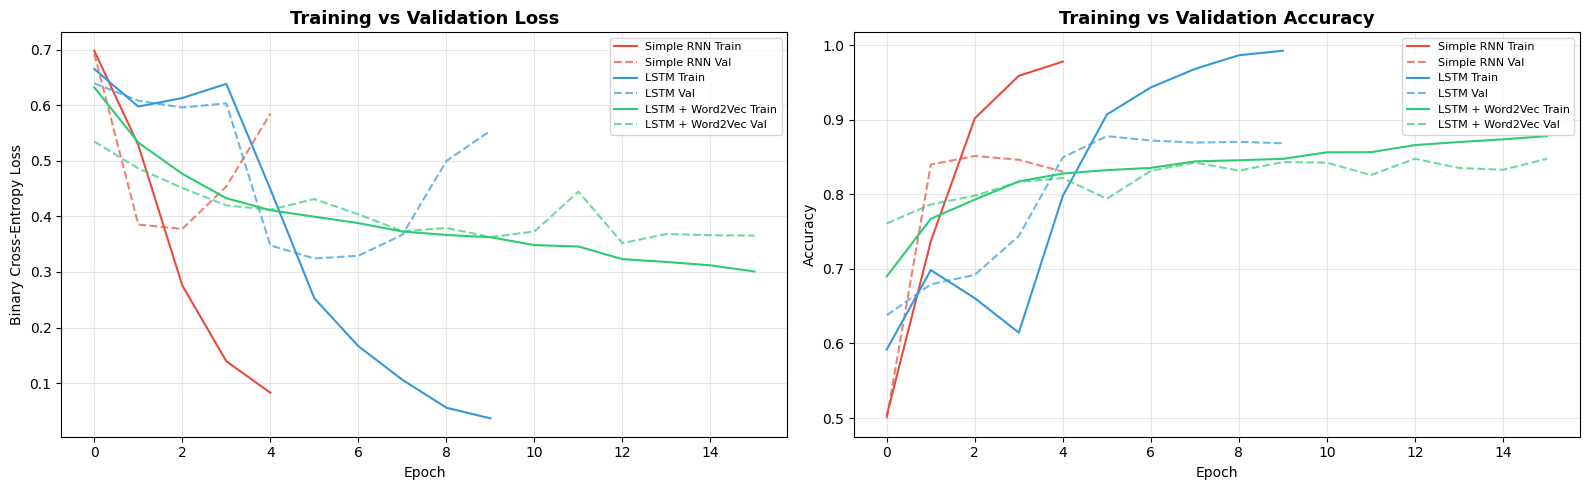

 All training curves plotted.


In [ ]:
def plot_history(histories, names, colors):
    """Plot training vs validation loss and accuracy for all models."""
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    for h, name, color in zip(histories, names, colors):
        axes[0].plot(h.history['loss'],     linestyle='-',  color=color, label=f'{name} Train')
        axes[0].plot(h.history['val_loss'], linestyle='--', color=color, label=f'{name} Val', alpha=0.7)
        axes[1].plot(h.history['accuracy'],     linestyle='-',  color=color, label=f'{name} Train')
        axes[1].plot(h.history['val_accuracy'], linestyle='--', color=color, label=f'{name} Val', alpha=0.7)

    axes[0].set_title('Training vs Validation Loss', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Binary Cross-Entropy Loss')
    axes[0].legend(fontsize=8)
    axes[0].grid(True, alpha=0.3)

    axes[1].set_title('Training vs Validation Accuracy', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend(fontsize=8)
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    return fig

histories = [history1, history2, history3]
names     = ['Simple RNN', 'LSTM', 'LSTM + Word2Vec']
colors    = ['#e74c3c', '#3498db', '#2ecc71']

fig = plot_history(histories, names, colors)
plt.savefig('training_curves_all.png', dpi=150, bbox_inches='tight')
plt.show()
print(" All training curves plotted.")


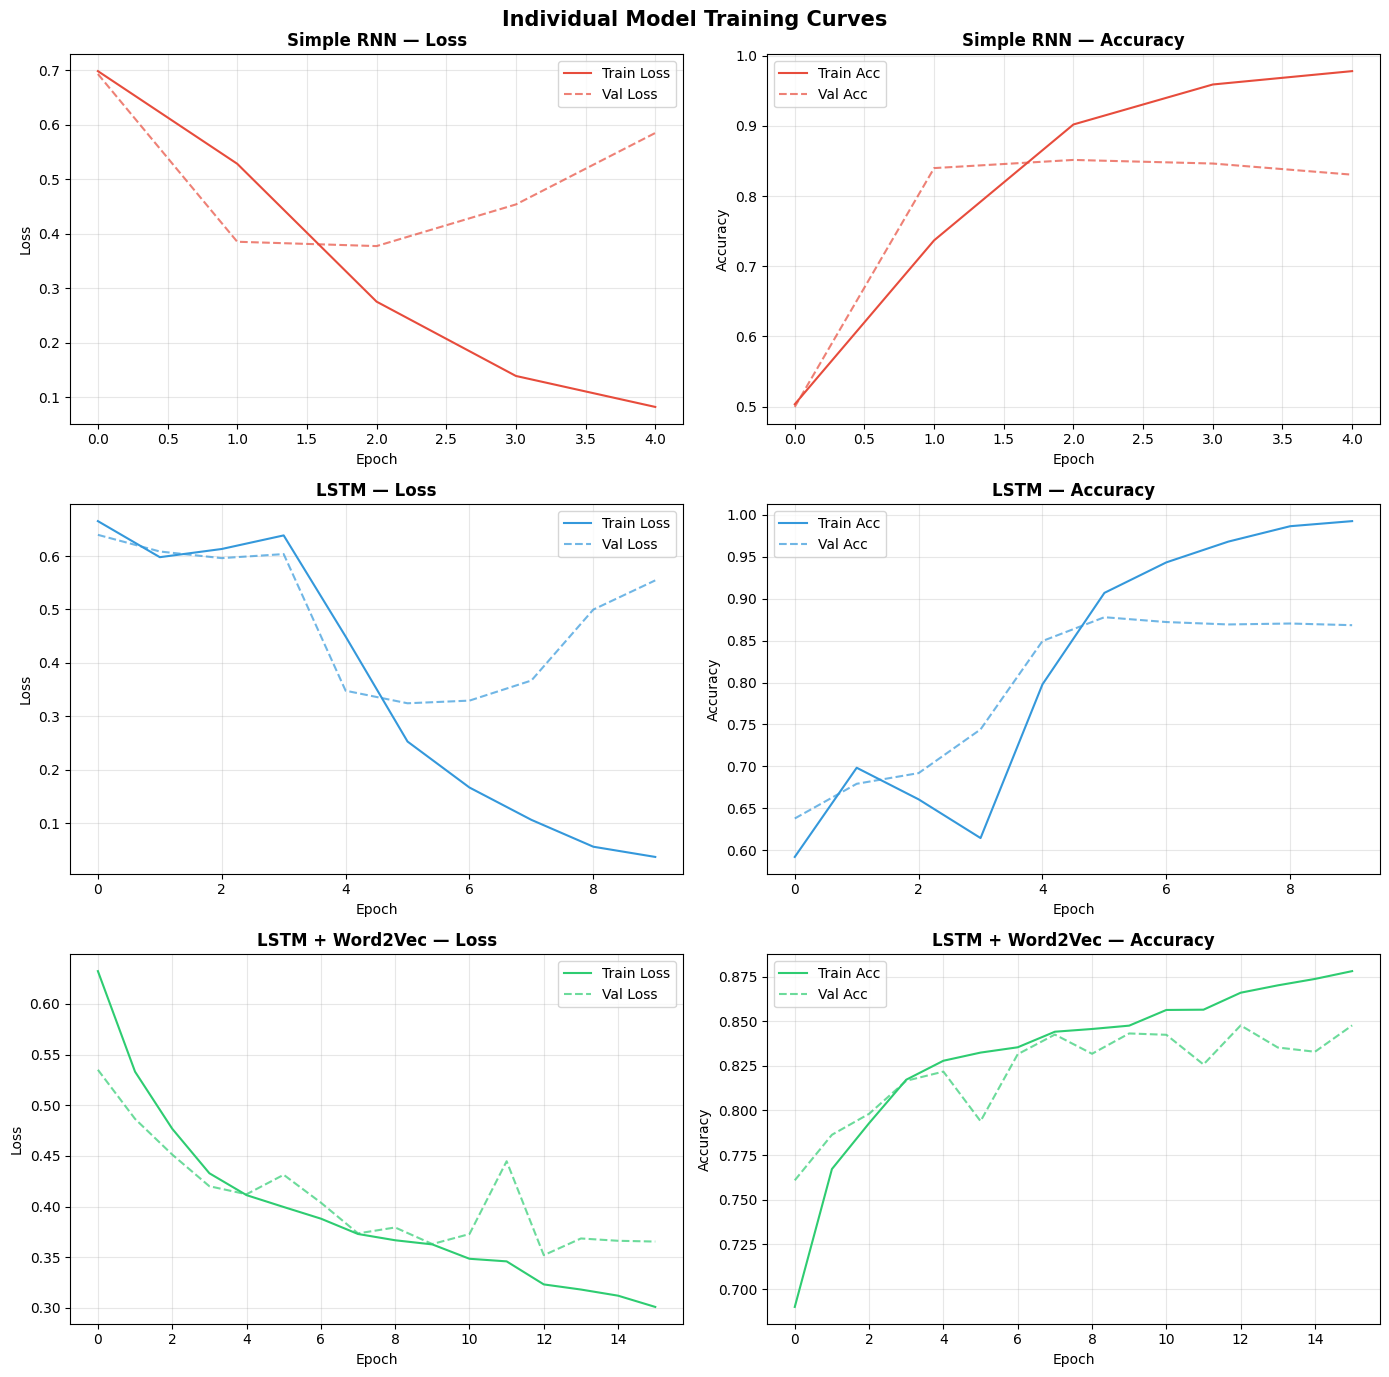

In [ ]:
# ── Individual model plots ──
fig, axes = plt.subplots(3, 2, figsize=(14, 14))

for i, (h, name, color) in enumerate(zip(histories, names, colors)):
    axes[i, 0].plot(h.history['loss'],     color=color, label='Train Loss')
    axes[i, 0].plot(h.history['val_loss'], color=color, linestyle='--', alpha=0.7, label='Val Loss')
    axes[i, 0].set_title(f'{name} — Loss', fontweight='bold')
    axes[i, 0].set_xlabel('Epoch')
    axes[i, 0].set_ylabel('Loss')
    axes[i, 0].legend()
    axes[i, 0].grid(True, alpha=0.3)

    axes[i, 1].plot(h.history['accuracy'],     color=color, label='Train Acc')
    axes[i, 1].plot(h.history['val_accuracy'], color=color, linestyle='--', alpha=0.7, label='Val Acc')
    axes[i, 1].set_title(f'{name} — Accuracy', fontweight='bold')
    axes[i, 1].set_xlabel('Epoch')
    axes[i, 1].set_ylabel('Accuracy')
    axes[i, 1].legend()
    axes[i, 1].grid(True, alpha=0.3)

plt.suptitle('Individual Model Training Curves', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('training_curves_individual.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 7. Model Evaluation

Each model is evaluated on the **test set** using:
- **Accuracy**
- **Confusion Matrix**
- **Classification Report** (Precision, Recall, F1-Score)


In [ ]:
def evaluate_model(model, X_test, y_test, name):
    """Full evaluation: accuracy, confusion matrix, classification report."""
    y_pred_prob = model.predict(X_test, verbose=0)
    y_pred      = (y_pred_prob >= 0.5).astype(int).flatten()

    acc    = accuracy_score(y_test, y_pred)
    cm     = confusion_matrix(y_test, y_pred)
    report = classification_report(y_test, y_pred,
                                   target_names=['Negative', 'Positive'])

    print(f"{'='*55}")
    print(f"  Model : {name}")
    print(f"{'='*55}")
    print(f"  Test Accuracy : {acc*100:.2f}%")
    print(f"\nClassification Report:")
    print(report)

    return y_pred, cm, acc, report

print("\n Evaluating all models on test set...")
y_pred1, cm1, acc1, rep1 = evaluate_model(model1, X_test_rnn, y_test, "Simple RNN")  # ← X_test_rnn
y_pred2, cm2, acc2, rep2 = evaluate_model(model2, X_test, y_test, "LSTM")             # ← fine
y_pred3, cm3, acc3, rep3 = evaluate_model(model3, X_test, y_test, "LSTM + Word2Vec")  # ← fine



 Evaluating all models on test set...
  Model : Simple RNN
  Test Accuracy : 85.09%

Classification Report:
              precision    recall  f1-score   support

    Negative       0.86      0.84      0.85      4961
    Positive       0.84      0.87      0.85      5039

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000

  Model : LSTM
  Test Accuracy : 87.63%

Classification Report:
              precision    recall  f1-score   support

    Negative       0.90      0.84      0.87      4961
    Positive       0.85      0.91      0.88      5039

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000

  Model : LSTM + Word2Vec
  Test Accuracy : 84.61%

Classification Report:
              precision    recall  f1-score   support

    Negative       0.86      0.83      0.84

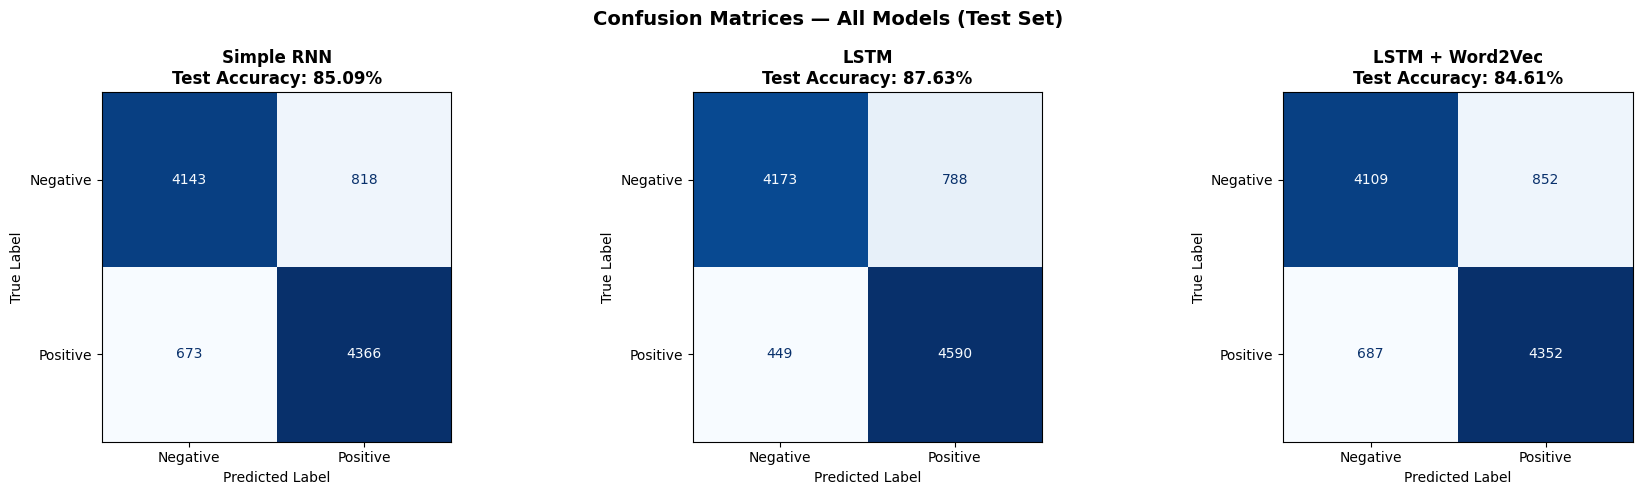

In [ ]:
# ── Confusion Matrix Visualization ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
cms   = [cm1, cm2, cm3]
accs  = [acc1, acc2, acc3]

for ax, cm, name, color, acc in zip(axes, cms, names, colors, accs):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['Negative', 'Positive'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'{name}\nTest Accuracy: {acc*100:.2f}%',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

plt.suptitle('Confusion Matrices — All Models (Test Set)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# ── Performance Comparison Table ──
from sklearn.metrics import precision_score, recall_score, f1_score

results = []
for y_pred, name, t in zip([y_pred1, y_pred2, y_pred3], names, [m1_time, m2_time, m3_time]):
    results.append({
        'Model'         : name,
        'Accuracy (%)'  : round(accuracy_score(y_test, y_pred) * 100, 2),
        'Precision'     : round(precision_score(y_test, y_pred), 4),
        'Recall'        : round(recall_score(y_test, y_pred), 4),
        'F1-Score'      : round(f1_score(y_test, y_pred), 4),
        'Train Time (s)': round(t, 1),
    })

results_df = pd.DataFrame(results)
print("\n Performance Comparison Table:")
print(results_df.to_string(index=False))
results_df



 Performance Comparison Table:
          Model  Accuracy (%)  Precision  Recall  F1-Score  Train Time (s)
     Simple RNN         85.09     0.8422  0.8664    0.8542            51.6
           LSTM         87.63     0.8535  0.9109    0.8813           110.6
LSTM + Word2Vec         84.61     0.8363  0.8637    0.8498           142.2


,Model,Accuracy (%),Precision,Recall,F1-Score,Train Time (s)
0,Simple RNN,85.09,0.8422,0.8664,0.8542,51.6
1,LSTM,87.63,0.8535,0.9109,0.8813,110.6
2,LSTM + Word2Vec,84.61,0.8363,0.8637,0.8498,142.2


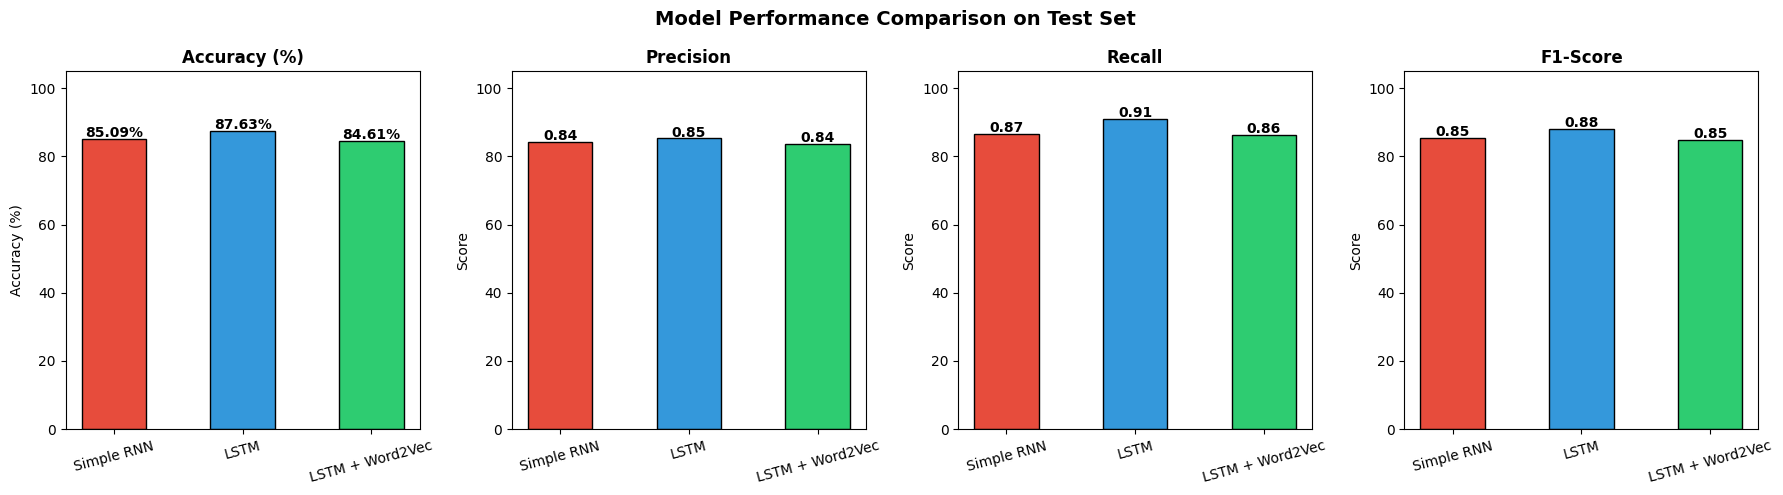

In [ ]:
# ── Bar Chart: Model Comparison ──
metrics = ['Accuracy (%)', 'Precision', 'Recall', 'F1-Score']
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for ax, metric in zip(axes, metrics):
    vals = results_df[metric].values
    if metric == 'Accuracy (%)':
        vals_plot = vals
    else:
        vals_plot = vals * 100   # convert to % for visual consistency

    bars = ax.bar(names, vals_plot if metric != 'Accuracy (%)' else vals,
                  color=colors, edgecolor='black', width=0.5)
    ax.set_title(metric, fontweight='bold', fontsize=12)
    ax.set_ylabel('Score' if metric != 'Accuracy (%)' else 'Accuracy (%)')
    ax.set_ylim(0, 105)
    ax.tick_params(axis='x', rotation=15)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.5,
                f'{v:.2f}{"%" if metric=="Accuracy (%)" else ""}',
                ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Model Performance Comparison on Test Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 8. Error Analysis

Analyzing misclassified examples to understand model weaknesses and suggest improvements.


In [ ]:
# ── Find misclassified samples for best model (Model 3) ──
test_df_copy = test_df.copy().reset_index(drop=True)
test_df_copy['pred_m3']   = y_pred3
test_df_copy['pred_m2']   = y_pred2
test_df_copy['pred_m1']   = y_pred1

# Misclassified by all 3 models
all_wrong = test_df_copy[
    (test_df_copy['pred_m3'] != test_df_copy['sentiment']) &
    (test_df_copy['pred_m2'] != test_df_copy['sentiment']) &
    (test_df_copy['pred_m1'] != test_df_copy['sentiment'])
].reset_index(drop=True)

print(f"Total test samples         : {len(test_df_copy)}")
print(f"Misclassified by all 3     : {len(all_wrong)}")
print(f"Error rate (all 3 wrong)   : {len(all_wrong)/len(test_df_copy)*100:.2f}%\n")

# Show 3 misclassified examples
print("=" * 70)
print("MISCLASSIFIED EXAMPLES (all 3 models wrong)")
print("=" * 70)
label_map = {0: 'Negative', 1: 'Positive'}

for i in range(min(3, len(all_wrong))):
    row = all_wrong.iloc[i]
    print(f"\nExample {i+1}:")
    print(f"  True Label      : {label_map[int(row['sentiment'])]}")
    print(f"  Model1 Pred     : {label_map[int(row['pred_m1'])]}")
    print(f"  Model2 Pred     : {label_map[int(row['pred_m2'])]}")
    print(f"  Model3 Pred     : {label_map[int(row['pred_m3'])]}")
    print(f"  Review (snippet): {row['review'][:300]}...")
    print("-" * 70)


Total test samples         : 10000
Misclassified by all 3     : 466
Error rate (all 3 wrong)   : 4.66%

MISCLASSIFIED EXAMPLES (all 3 models wrong)

Example 1:
  True Label      : Positive
  Model1 Pred     : Negative
  Model2 Pred     : Negative
  Model3 Pred     : Negative
  Review (snippet): I really liked this Summerslam due to the look of the arena, the curtains and just the look overall was interesting to me for some reason. Anyways, this could have been one of the best Summerslam's ever if the WWF didn't have Lex Luger in the main event against Yokozuna, now for it's time it was ok ...
----------------------------------------------------------------------

Example 2:
  True Label      : Positive
  Model1 Pred     : Negative
  Model2 Pred     : Negative
  Model3 Pred     : Negative
  Review (snippet): Three kids are born during a solar eclipse and turn into vile murderous little tykes who're above suspicion by everyone, save for Joyce (Lori Lethin) and her younger brother Timmy. 

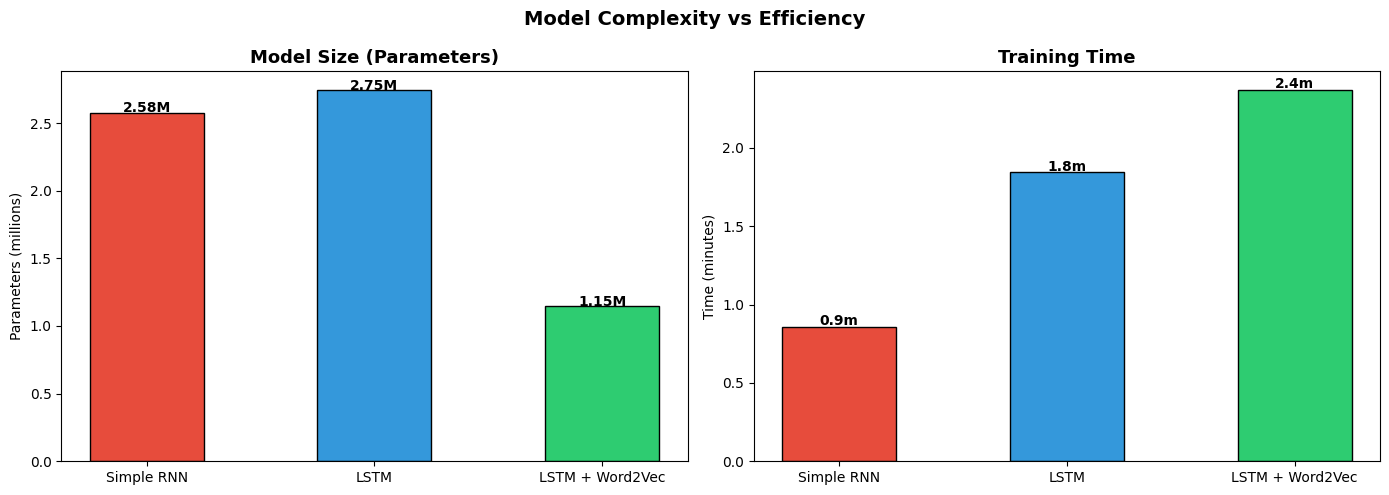


 Parameter Counts:
  Simple RNN                    :  2,577,633 parameters
  LSTM                          :  2,745,217 parameters
  LSTM + Word2Vec               :  1,145,281 parameters


In [ ]:
# ── Model Complexity vs Performance ──
param_counts = [model1.count_params(), model2.count_params(), model3.count_params()]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Parameters
axes[0].bar(names, [p/1e6 for p in param_counts], color=colors, edgecolor='black', width=0.5)
axes[0].set_title('Model Size (Parameters)', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Parameters (millions)')
for i, (bar, p) in enumerate(zip(axes[0].patches, param_counts)):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.002,
                 f'{p/1e6:.2f}M', ha='center', fontweight='bold')

# Training time
times = [m1_time, m2_time, m3_time]
axes[1].bar(names, [t/60 for t in times], color=colors, edgecolor='black', width=0.5)
axes[1].set_title('Training Time', fontweight='bold', fontsize=13)
axes[1].set_ylabel('Time (minutes)')
for bar, t in zip(axes[1].patches, times):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.01,
                 f'{t/60:.1f}m', ha='center', fontweight='bold')

plt.suptitle('Model Complexity vs Efficiency', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('complexity_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n Parameter Counts:")
for name, p in zip(names, param_counts):
    print(f"  {name:30s}: {p:>10,} parameters")


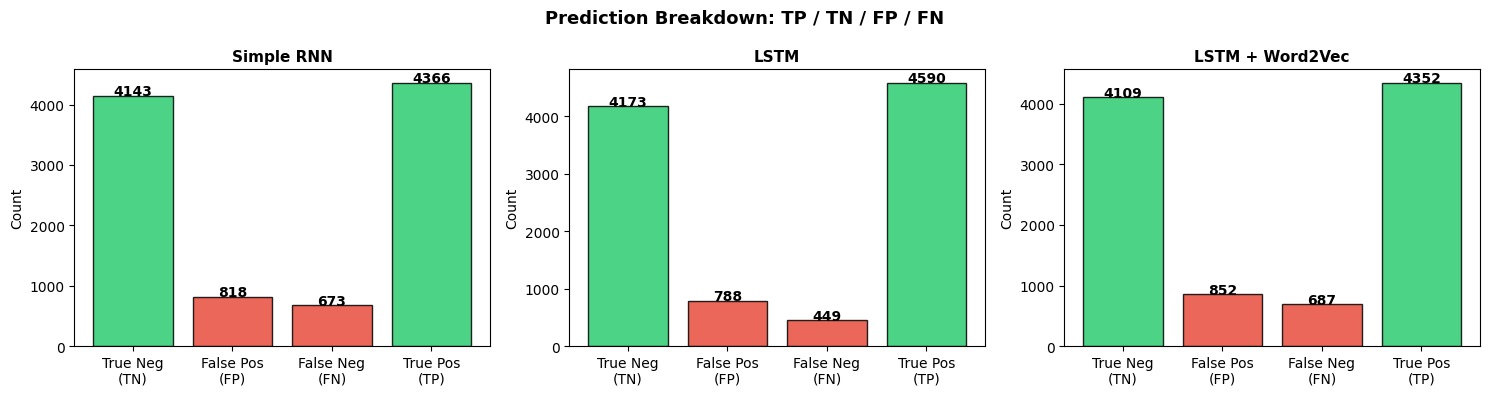

In [ ]:
# ── Error analysis: FP vs FN breakdown ──
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, cm, name in zip(axes, [cm1, cm2, cm3], names):
    tn, fp, fn, tp = cm.ravel()
    bars = ax.bar(['True Neg\n(TN)', 'False Pos\n(FP)', 'False Neg\n(FN)', 'True Pos\n(TP)'],
                  [tn, fp, fn, tp],
                  color=['#2ecc71', '#e74c3c', '#e74c3c', '#2ecc71'],
                  edgecolor='black', alpha=0.85)
    ax.set_title(f'{name}', fontweight='bold', fontsize=11)
    ax.set_ylabel('Count')
    for bar, v in zip(bars, [tn, fp, fn, tp]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 10, str(v),
                ha='center', fontweight='bold', fontsize=10)

plt.suptitle('Prediction Breakdown: TP / TN / FP / FN', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('error_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()


### Why Did the Models Fail on These Examples?

Looking at the misclassified reviews, there are three main reasons the models got them wrong:

1. **Mixed feelings in one review** — Some reviews say good things about
   the acting but bad things about the story. The model reads the whole
   review as one and gets confused because it cannot separate which part
   is positive and which is negative.

2. **Sarcasm** — Sometimes a reviewer writes "oh great, another boring film"
   in a sarcastic way. After cleaning, the word "great" looks positive to
   the model, but the reviewer actually meant the opposite. The model has
   no way to detect this.

3. **Very short reviews after cleaning** — After removing stopwords and
   common words, some reviews become very short — just 5 to 10 words.
   With so little text left, the model does not have enough information
   to make a correct prediction.

### What Could Be Done Better

- **Bidirectional LSTM** — Instead of reading the review only left to right,
  read it both ways. This helps the model understand words in better context.
- **Attention layer** — Let the model focus more on important words like
  "terrible" or "loved" instead of treating every word equally.
- **Bigger word embeddings** — We used GloVe with 50 dimensions. Using
  300 dimensions would give the model a richer understanding of words.
- **BERT** — A more advanced model that understands full sentence context.
  It would handle sarcasm and mixed reviews much better than RNN or LSTM.

---
## 9. Real-Time Prediction GUI (Gradio)

A simple interactive interface where a user can type a movie review and get an instant sentiment prediction from all three models.



In [ ]:
# ── Install Gradio (uncomment if needed) ──
!pip install gradio


In [ ]:
# ── Save all models and tokenizer ──


model1.save('model_rnn.keras')
model2.save('model_lstm.keras')
model3.save('model_lstm_w2v.keras')

with open('tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

print(" Saved successfully.")

 Saved successfully.


In [ ]:


model1 = load_model('model_rnn.keras')
model2 = load_model('model_lstm.keras')
model3 = load_model('model_lstm_w2v.keras')

with open('tokenizer.pkl', 'rb') as f:
    tokenizer = pickle.load(f)

MAX_LEN = 150
RNN_MAX_LEN = 100  # ← add this line too, just in case

print(" Models loaded:", model1.name, "|", model2.name, "|", model3.name)
print(" Tokenizer loaded — vocab size:", len(tokenizer.word_index))

 Models loaded: Simple_RNN | LSTM_Model | LSTM_Word2Vec_Embedding
 Tokenizer loaded — vocab size: 74194


In [ ]:


def predict_sentiment(review_text):
    """Clean input, tokenize, pad and predict with all 3 models."""
    if not review_text.strip():
        return " Please enter a review.", "", ""

    cleaned   = clean_text(review_text)
    sequence  = tokenizer.texts_to_sequences([cleaned])
    padded    = pad_sequences(sequence, maxlen=MAX_LEN, padding='post', truncating='post')

    label_map = {0: ' Negative', 1: ' Positive'}

    def fmt(model, name):
        prob  = float(model.predict(padded, verbose=0)[0][0])
        label = label_map[int(prob >= 0.5)]
        conf  = prob if prob >= 0.5 else 1 - prob
        return f"{label}  (Confidence: {conf*100:.1f}%)"

    return fmt(model1, 'RNN'), fmt(model2, 'LSTM'), fmt(model3, 'LSTM+Word2Vec')

# ── Build Gradio UI ──
with gr.Blocks(title="IMDb Sentiment Analyzer") as demo:
    gr.Markdown("#  IMDb Movie Review Sentiment Analyzer")
    gr.Markdown("Enter a movie review below to get sentiment predictions from all three models.")

    with gr.Row():
        review_input = gr.Textbox(
            label="Enter Movie Review",
            placeholder="Type your movie review here...",
            lines=5
        )

    predict_btn = gr.Button(" Analyze Sentiment", variant="primary")

    with gr.Row():
        out1 = gr.Textbox(label="Simple RNN")
        out2 = gr.Textbox(label="LSTM")
        out3 = gr.Textbox(label="LSTM + Word2Vec")

    gr.Examples(
        examples=[
            ["This movie was absolutely fantastic! The acting was superb and the story was breathtaking."],
            ["Terrible film. Boring, predictable and a complete waste of time. I walked out halfway through."],
            ["It had its moments but overall the pacing was off and the ending felt rushed."],
        ],
        inputs=review_input
    )

    predict_btn.click(fn=predict_sentiment,
                      inputs=review_input,
                      outputs=[out1, out2, out3])

demo.launch(share=True)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://98a6e7786835964143.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
# ── Final Summary Print ──
print("=" * 60)
print("        FINAL MODEL PERFORMANCE SUMMARY")
print("=" * 60)
print(results_df.to_string(index=False))
print("=" * 60)
best_idx = results_df['Accuracy (%)'].idxmax()
print(f"\n Best Model : {results_df.loc[best_idx, 'Model']}")
print(f"   Accuracy   : {results_df.loc[best_idx, 'Accuracy (%)']:.2f}%")
print(f"   F1-Score   : {results_df.loc[best_idx, 'F1-Score']:.4f}")
print("=" * 60)


        FINAL MODEL PERFORMANCE SUMMARY
          Model  Accuracy (%)  Precision  Recall  F1-Score  Train Time (s)
     Simple RNN         85.09     0.8422  0.8664    0.8542            51.6
           LSTM         87.63     0.8535  0.9109    0.8813           110.6
LSTM + Word2Vec         84.61     0.8363  0.8637    0.8498           142.2

 Best Model : LSTM
   Accuracy   : 87.63%
   F1-Score   : 0.8813
